In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [4]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)


In [6]:
X

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]])

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [9]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [10]:
model = Sequential()
model.add(Dense(64,activation = 'relu',input_dim = 8))

model.add(Dense(32,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics =['accuracy'])

In [13]:
history = model.fit(X_train,y_train,epochs = 100,batch_size = 32,validation_data = (X_test,y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5465 - loss: 0.6945 - val_accuracy: 0.6818 - val_loss: 0.6151
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.7154 - loss: 0.5904 - val_accuracy: 0.7013 - val_loss: 0.5675
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.7630 - loss: 0.5339 - val_accuracy: 0.7468 - val_loss: 0.5409
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - accuracy: 0.7733 - loss: 0.5021 - val_accuracy: 0.7403 - val_loss: 0.5302
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.7991 - loss: 0.4680 - val_accuracy: 0.7468 - val_loss: 0.5205
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - accuracy: 0.7971 - loss: 0.4694 - val_accuracy: 0.7532 - val_loss: 0.5171
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step - accuracy: 0.7856 - loss: 0.4516 - val_accuracy: 0.7597 - val_loss: 0.5150
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.7814 - loss: 0.4410 - val_accura

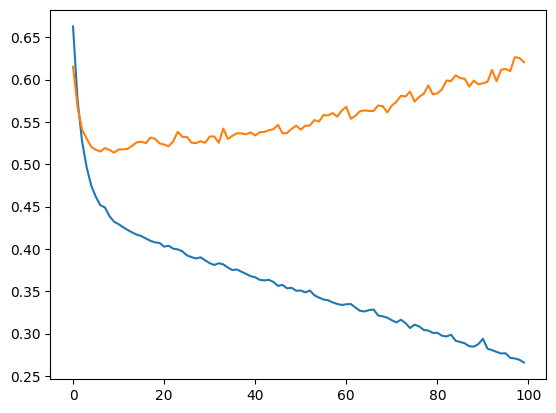

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [27]:
import tensorflow

In [29]:
model_1 = Sequential()

model_1.add(Dense(64,activation = 'relu',input_dim = 8,kernel_regularizer=tensorflow.keras.regularizers.l2(0.02)))
model_1.add(Dropout(0.5))
model_1.add(Dense(32,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.l2(0.02)))
model_1.add(Dropout(0.5))
model_1.add(Dense(1,activation = 'sigmoid'))

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model_1.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics = ['accuracy'])

In [35]:
history1 = model_1.fit(X_train,y_train,epochs =500,validation_data = (X_test,y_test))

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4615 - loss: 1.9185 - val_accuracy: 0.7013 - val_loss: 1.6505
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.5669 - loss: 1.6826 - val_accuracy: 0.7208 - val_loss: 1.4820
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.6819 - loss: 1.4894 - val_accuracy: 0.7273 - val_loss: 1.3515
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 0.6876 - loss: 1.3327 - val_accuracy: 0.7338 - val_loss: 1.2399
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.6831 - loss: 1.2560 - val_accuracy: 0.7403 - val_loss: 1.1459
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 742us/step - accuracy: 0.6966 - loss: 1.1525 - val_accuracy: 0.7403 - val_loss: 1.0639
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.6971 - loss: 1.0655 - val_accuracy: 0.7857 - val_loss: 0.9924
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.7214 - loss: 0.9957 - val_accura

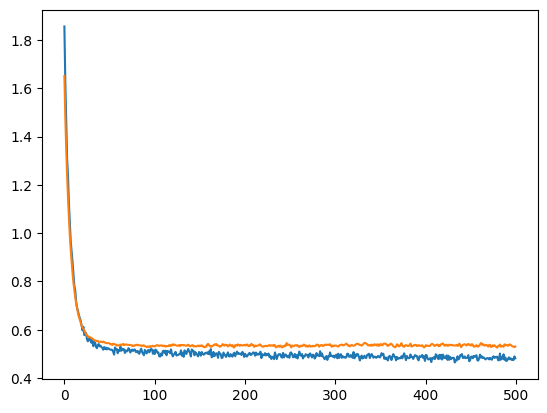

In [37]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [39]:
import tensorflow as tf
import keras_tuner as kt

In [41]:
#optimizer choosing thru hyperparams
def build_model(hp):
    model = Sequential()
   
    model.add(Dense(64,activation = 'relu'))
    model.add(Dense(32,activation = 'relu'))
    model.add(Dense(1,activation = 'sigmoid'))
    
   

    model.compile(optimizer = hp.Choice('optimizer',values= ['adam','sgd','rmsprop','adadelta']),
                                        loss = 'binary_crossentropy',metrics =['accuracy'])
    return model

In [43]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
)

Reloading Tuner from ./untitled_project/tuner0.json


In [45]:
tuner.search(X_train,y_train,epochs = 10,validation_data = (X_test,y_test))

In [47]:
tuner.get_best_hyperparameters()[0].values

{'optimizer': 'adam'}

In [49]:
model = tuner.get_best_models(num_models = 1)[0]

/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [51]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.fit(X_train,y_train,epochs = 100,initial_epoch = 6,batch_size = 32,validation_data = (X_test,y_test))

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7591 - loss: 0.4963 - val_accuracy: 0.7987 - val_loss: 0.4940
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.7637 - loss: 0.4917 - val_accuracy: 0.7597 - val_loss: 0.4918
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step - accuracy: 0.7629 - loss: 0.4551 - val_accuracy: 0.7597 - val_loss: 0.4967
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 790us/step - accuracy: 0.7899 - loss: 0.4429 - val_accuracy: 0.7532 - val_loss: 0.4989
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.8187 - loss: 0.4106 - val_accuracy: 0.7532 - val_loss: 0.5001
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.7922 - loss: 0.4300 - val_accuracy: 0.7597 - val_loss: 0.5017
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.8162 - loss: 0.4043 - val_accuracy: 0.7597 - val_loss: 0.5087
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.8065 - loss: 0.4179 - val_a

In [55]:
def build_model(hp):
    model = Sequential()

    units1 = hp.Int('units1', min_value=8, max_value=128)
    model.add(Dense(units1, activation='relu'))

    units2 = hp.Int('units2',min_value = 8,max_value =128)
    model.add(Dense(units2, activation='relu'))
    
    model.add(Dense(1,activation = 'sigmoid'))

    model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics =['accuracy'])
    return model
    

In [57]:
tuner1 = kt.RandomSearch(build_model,objective ='val_accuracy',max_trials = 5,directory = 'mydir',project_name = 'srr')

Reloading Tuner from mydir/srr/tuner0.json


In [59]:
tuner1.search(X_train,y_train,epochs = 10,validation_data = (X_test,y_test),verbose =2)

In [61]:
tuner1.get_best_hyperparameters()[0].values

{'units1': 55, 'units2': 39}

In [63]:
model = tuner1.get_best_models(num_models=1)[0]

/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [65]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 55)             │           495 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │         2,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            40 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,719 (10.62 KB)

 Trainable params: 2,719 (10.62 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.fit(X_train,y_train,epochs = 100,validation_data =(X_test,y_test),initial_epoch = 6)

Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7723 - loss: 0.4597 - val_accuracy: 0.7857 - val_loss: 0.4842
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step - accuracy: 0.7877 - loss: 0.4436 - val_accuracy: 0.7792 - val_loss: 0.4860
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.7865 - loss: 0.4494 - val_accuracy: 0.7857 - val_loss: 0.4909
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step - accuracy: 0.7834 - loss: 0.4361 - val_accuracy: 0.7662 - val_loss: 0.4885
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 814us/step - accuracy: 0.7930 - loss: 0.4284 - val_accuracy: 0.7597 - val_loss: 0.4927
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step - accuracy: 0.8126 - loss: 0.4283 - val_accuracy: 0.7662 - val_loss: 0.4962
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 751us/step - accuracy: 0.7985 - loss: 0.4296 - val_accuracy: 0.7662 - val_loss: 0.4939
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - accuracy: 0.8151 - loss: 0.4235 - val_a

In [69]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(55,activation = 'relu',input_dim = 8))
    for i in range(hp.Int('num_layers',min_value = 1,max_value = 10)):
        model.add(Dense(32,activation = 'relu'))
    model.add(Dense(1,activation = 'sigmoid'))

    model.compile(loss = 'binary_crossentropy',optimizer = 'Adam',metrics = ['accuracy'])
    return model

In [71]:
tuner2 = kt.RandomSearch(build_model,objective = 'val_accuracy',max_trials = 5,directory = 'mydir',project_name = 'krr')

Reloading Tuner from mydir/krr/tuner0.json


In [73]:
tuner2.search(X_train,y_train,epochs = 10,validation_data =(X_test,y_test),verbose=2)

In [75]:
tuner2.get_best_hyperparameters()[0].values

{'num_layers': 9}

In [77]:
model = tuner2.get_best_models(num_models = 1)[0]

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [79]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 55)             │           495 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,768 (42.06 KB)

 Trainable params: 10,768 (42.06 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.fit(X_train,y_train,epochs=100,initial_epoch = 5,validation_data = (X_test,y_test))

Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7597 - loss: 0.4718 - val_accuracy: 0.7338 - val_loss: 0.5400
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 976us/step - accuracy: 0.7905 - loss: 0.4374 - val_accuracy: 0.7597 - val_loss: 0.5354
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8274 - loss: 0.3834 - val_accuracy: 0.7597 - val_loss: 0.5422
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8174 - loss: 0.4012 - val_accuracy: 0.7922 - val_loss: 0.5623
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8206 - loss: 0.3868 - val_accuracy: 0.7792 - val_loss: 0.5628
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - accuracy: 0.8116 - loss: 0.3960 - val_accuracy: 0.7273 - val_loss: 0.5609
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - accuracy: 0.8185 - loss: 0.3890 - val_accuracy: 0.7078 - val_loss: 0.5845
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.8346 - loss: 0.3779 - val_accura

In [ ]:
def build_model(hp):
    model = Sequential()
    
   
    model.add(Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),  
        activation=hp.Choice('activation_input', values=['relu', 'tanh', 'sigmoid']),  
        input_dim=8  # Assuming 8 input features
    ))
    

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)): 
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),  
            activation=hp.Choice(f'activation_{i}', values=['relu', 'tanh', 'sigmoid'])  
        ))

    
    model.add(Dense(1, activation='sigmoid'))


    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    model.compile(loss = 'binary_crossentropy',optimizer=optimizer,metrics = ['accuracy'])
    return model

In [ ]:
tuner3 = kt.RandomSearch(build_model,objective = 'val_accuracy',max_trials = 5,directory = 'mydir',project_name = 'qwe')

In [ ]:
tuner3.search(X_train,y_train,epochs = 20,validation_data = (X_test,y_test),verbose=2)

In [ ]:
tuner3.get_best_hyperparameters()[0].values

In [ ]:
model = tuner3.get_best_models(num_models=1)[0]

In [ ]:
model.summary()

In [ ]:
history5 = model.fit(X_train,y_train,epochs = 500,validation_data = (X_test,y_test),initial_epoch = 5)

In [89]:
def build_model(hp):
    model = Sequential()
    
   
    model.add(Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),  
        activation=hp.Choice('activation_input', values=['relu', 'tanh', 'sigmoid']),  
        input_dim=8  # Assuming 8 input features
    ))
    

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)): 
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=128, step=16),  
            activation=hp.Choice(f'activation_{i}', values=['relu', 'tanh', 'sigmoid'])  
        ))

    
    model.add(Dense(1, activation='sigmoid'))


    optimizer = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop'])
    loss = hp.Choice('loss',values= ['binary_crossentropy','sparse_categorical_crossentropy'])
    model.compile(loss = loss,optimizer=optimizer,metrics = ['accuracy'])
    return model

In [93]:
tuner3 = kt.RandomSearch(build_model,objective = 'val_accuracy',max_trials = 5,directory = 'mydir',project_name = 'arrrr')

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:
tuner3.search(X_train,y_train,epochs =20,validation_data = (X_test,y_test),verbose = 2)

In [101]:
tuner3.get_best_hyperparameters()[0].values

{'units_input': 96,
 'activation_input': 'tanh',
 'num_layers': 4,
 'units_0': 112,
 'activation_0': 'sigmoid',
 'optimizer': 'sgd',
 'loss': 'binary_crossentropy',
 'units_1': 16,
 'activation_1': 'relu',
 'units_2': 16,
 'activation_2': 'relu',
 'units_3': 16,
 'activation_3': 'relu'}

In [103]:
models = tuner3.get_best_models(num_models = 1)[0]

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [107]:
history5 = models.fit(X_train,y_train,epochs =200,initial_epoch = 5,validation_data = (X_test,y_test))

Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7761 - loss: 0.4674 - val_accuracy: 0.7857 - val_loss: 0.5041
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - accuracy: 0.7553 - loss: 0.4834 - val_accuracy: 0.7857 - val_loss: 0.5043
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - accuracy: 0.7686 - loss: 0.4484 - val_accuracy: 0.7727 - val_loss: 0.5019
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.7582 - loss: 0.4644 - val_accuracy: 0.7857 - val_loss: 0.5030
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step - accuracy: 0.7685 - loss: 0.4639 - val_accuracy: 0.7922 - val_loss: 0.5235
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.7718 - loss: 0.4873 - val_accuracy: 0.7727 - val_loss: 0.5034
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - accuracy: 0.7914 - loss: 0.4464 - val_accuracy: 0.7857 - val_loss: 0.5040
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.8034 - loss: 0.4478 - val_ac